In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import shap
from sklearn.preprocessing import StandardScaler

# 1. Train the optimal ML model

In [2]:
df = pd.read_json('./data/MP_C12_selected_features.json')
df

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,...,minimum neighbor distance variation,MagpieData minimum AtomicWeight,max packing efficiency,MagpieData maximum CovalentRadius,MagpieData mean Number,min relative bond length,mean neighbor distance variation,MagpieData avg_dev MeltingT,MagpieData avg_dev Electronegativity,k_class
0,14,3,Cs(SbS2)2,AB2C4,416.924169,4.020155,mp-8890,-16.138279,-0.616589,0.000000,...,5.462055e-02,32.0650,0.311138,244,31.571429,0.924097,0.159347,217.458776,0.465306,1
1,5,3,KGeBr3,ABC3,175.640517,3.322678,mp-998412,-3.495008,-1.412312,0.025231,...,1.209678e-02,39.0983,0.384463,203,31.200000,0.787531,0.090941,296.933600,0.741600,1
2,4,3,LiAgF2,ABC2,51.295990,4.946592,mp-1176792,-9.631004,-2.133530,0.023437,...,1.054000e-07,6.9410,0.363430,145,17.000000,0.870218,0.132359,395.405000,1.262500,1
3,6,2,Sb2Os,AB2,130.076043,11.074427,mp-2695,-34.883281,-0.083994,0.000000,...,4.406832e-02,121.7600,0.446026,144,59.333333,0.920416,0.100005,1067.653333,0.066667,0
4,12,3,LiAgF4,ABC4,150.435277,4.212250,mp-752768,-7.883206,-1.843673,0.035738,...,1.442192e-16,6.9410,0.353018,145,14.333333,0.903046,0.102068,351.471111,1.122222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,14,3,In5AgSe8,AB5C8,408.163709,5.344296,mp-1224092,-3.944965,-0.758815,0.000000,...,1.559733e-01,78.9600,0.312321,145,40.285714,0.944346,0.183286,101.564694,0.364898,1
657,8,3,GeTe4Pb3,AB3C4,269.026576,7.435517,mp-1224448,-35.894271,-0.344737,0.042003,...,5.657788e-03,72.6400,0.488542,146,60.750000,0.973891,0.025433,118.354062,0.116250,0
658,7,3,Tl3AsS3,AB3C3,193.649007,6.725080,mp-9791,-3.978961,-0.521873,0.006070,...,9.032000e-02,32.0650,0.354918,145,46.285714,0.881517,0.136979,155.211429,0.421224,1
659,18,3,Li2PdF6,AB2C6,189.318076,4.110032,mp-13985,-7.451218,-2.287240,0.000000,...,6.322125e-04,6.9410,0.360448,139,11.777778,0.830062,0.115505,381.471111,1.152593,1


In [3]:
df.columns

Index(['nsites', 'nelements', 'formula_pretty', 'formula_anonymous', 'volume',
       'density', 'material_id', 'energy_per_atom',
       'formation_energy_per_atom', 'energy_above_hull', 'band_gap',
       'is_metal', 'structure_json', 'label', 'k_ao', 'k_log',
       'minimum neighbor distance variation',
       'MagpieData minimum AtomicWeight', 'max packing efficiency',
       'MagpieData maximum CovalentRadius', 'MagpieData mean Number',
       'min relative bond length', 'mean neighbor distance variation',
       'MagpieData avg_dev MeltingT', 'MagpieData avg_dev Electronegativity',
       'k_class'],
      dtype='object')

In [6]:
X = df.drop(['nsites', 'nelements', 'formula_pretty', 'formula_anonymous', 'volume',
       'density', 'material_id', 'energy_per_atom',
       'formation_energy_per_atom', 'energy_above_hull', 'band_gap',
       'is_metal', 'structure_json', 'label', 'k_ao', 'k_log', 
                'k_class'], axis = 1)

X

,minimum neighbor distance variation,MagpieData minimum AtomicWeight,max packing efficiency,MagpieData maximum CovalentRadius,MagpieData mean Number,min relative bond length,mean neighbor distance variation,MagpieData avg_dev MeltingT,MagpieData avg_dev Electronegativity
0,5.462055e-02,32.0650,0.311138,244,31.571429,0.924097,0.159347,217.458776,0.465306
1,1.209678e-02,39.0983,0.384463,203,31.200000,0.787531,0.090941,296.933600,0.741600
2,1.054000e-07,6.9410,0.363430,145,17.000000,0.870218,0.132359,395.405000,1.262500
3,4.406832e-02,121.7600,0.446026,144,59.333333,0.920416,0.100005,1067.653333,0.066667
4,1.442192e-16,6.9410,0.353018,145,14.333333,0.903046,0.102068,351.471111,1.122222
...,...,...,...,...,...,...,...,...,...
656,1.559733e-01,78.9600,0.312321,145,40.285714,0.944346,0.183286,101.564694,0.364898
657,5.657788e-03,72.6400,0.488542,146,60.750000,0.973891,0.025433,118.354062,0.116250
658,9.032000e-02,32.0650,0.354918,145,46.285714,0.881517,0.136979,155.211429,0.421224
659,6.322125e-04,6.9410,0.360448,139,11.777778,0.830062,0.115505,381.471111,1.152593


In [8]:
y = df["k_class"].values

In [30]:
param = {
    "random_state": 1998,
    "learning_rate": 0.04294897062505356,
    "iterations": 387,
    "l2_leaf_reg": 0.00015375354143706398,
    "depth": 6,
    "random_strength": 3,
    "bagging_temperature": 1.6076574305929292,
    "colsample_bylevel": 0.5636145604538867,
    "min_data_in_leaf": 37
    }

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.1, random_state = 2014, stratify = y)
cab = CatBoostClassifier(**param)
cab.fit(X_train, Y_train)
Y_pred_test = cab.predict_proba(X_test)[::, 1] 
#Y_pred_train = cab.predict(X_train) 
    
AUC_test = roc_auc_score(Y_test, Y_pred_test)
print("AUC value test:  ", AUC_test)

0:	learn: 0.6681587	total: 5.11ms	remaining: 1.97s
1:	learn: 0.6416643	total: 8.6ms	remaining: 1.66s
2:	learn: 0.6172305	total: 11.8ms	remaining: 1.52s
3:	learn: 0.5994028	total: 15.9ms	remaining: 1.53s
4:	learn: 0.5700543	total: 18.8ms	remaining: 1.43s
5:	learn: 0.5440376	total: 21.7ms	remaining: 1.38s
6:	learn: 0.5317607	total: 24.7ms	remaining: 1.34s
7:	learn: 0.5166478	total: 27.2ms	remaining: 1.29s
8:	learn: 0.5082304	total: 29.7ms	remaining: 1.25s
9:	learn: 0.4992869	total: 32.1ms	remaining: 1.21s
10:	learn: 0.4873112	total: 34.6ms	remaining: 1.18s
11:	learn: 0.4782090	total: 37ms	remaining: 1.16s
12:	learn: 0.4555735	total: 39.4ms	remaining: 1.13s
13:	learn: 0.4506899	total: 41.7ms	remaining: 1.11s
14:	learn: 0.4360576	total: 44ms	remaining: 1.09s
15:	learn: 0.4295652	total: 46.4ms	remaining: 1.07s
16:	learn: 0.4166917	total: 48.7ms	remaining: 1.06s
17:	learn: 0.4092942	total: 50.9ms	remaining: 1.04s
18:	learn: 0.4005808	total: 53ms	remaining: 1.03s
19:	learn: 0.3922832	total: 5

# 2. SHAP analysis based on the pre-trained model

In [40]:
shap.initjs()

## 2.1 Hierarchical clustering based on SHAP values

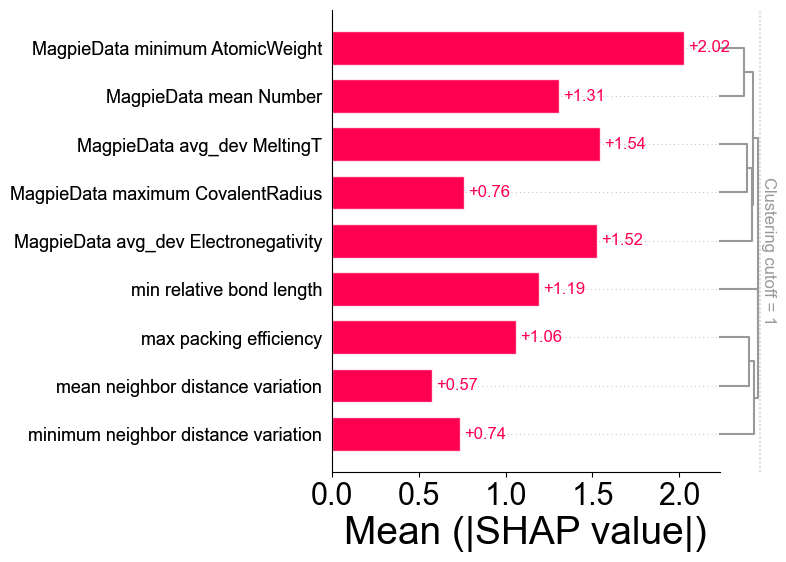

In [41]:
explainer = shap.Explainer(cab)
shap_values = explainer(X)

clust = shap.utils.hclust(X, y, linkage="average")
shap.plots.bar(shap_values, clustering=clust, clustering_cutoff=1, show=False)
fig = plt.gcf() # gcf means "get current figure"fig.set_figheight(11)fig.set_figwidth(9)
fig.set_figheight(6)
fig.set_figwidth(5)
plt.xticks(fontproperties = 'Arial',size = 22)
plt.xlabel('Mean (|SHAP value|)', fontsize=28,family='Arial')
#plt.savefig("shap_clust.svg",bbox_inches = 'tight',dpi=600) 
plt.show()

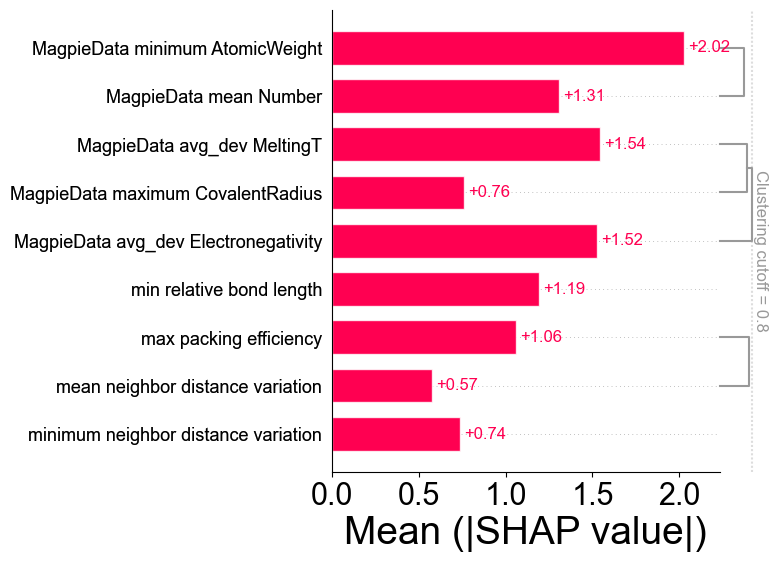

In [42]:
# Use different cutoff to identify different hierarchy
clust = shap.utils.hclust(X, y, linkage="average")
shap.plots.bar(shap_values, clustering=clust, clustering_cutoff=0.8, show=False)
fig = plt.gcf() # gcf means "get current figure"fig.set_figheight(11)fig.set_figwidth(9)
fig.set_figheight(6)
fig.set_figwidth(5)
plt.xticks(fontproperties = 'Arial',size = 22)
plt.xlabel('Mean (|SHAP value|)', fontsize=28,family='Arial')
plt.show()

## 2.2  Global interpretability

### The feature importance and the impact of different features on $\kappa_\mathrm{L}$

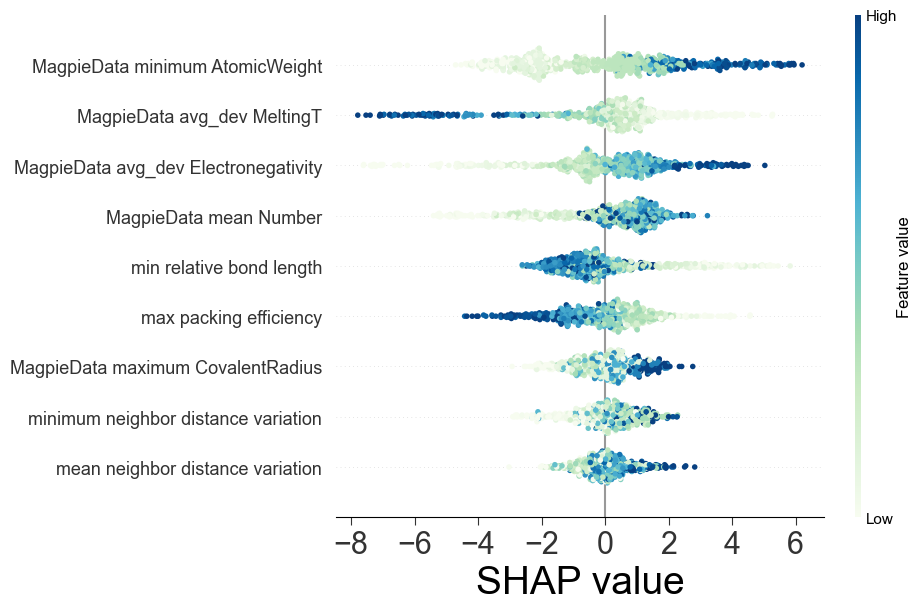

In [43]:
plt.rc('font',family='Arial')

shap.summary_plot(shap_values, X, show=False, cmap=plt.get_cmap("GnBu"))
#plt.rc('font',family='Arial', size=20)
fig = plt.gcf() 
fig.set_figheight(6)
fig.set_figwidth(11.5)
plt.xticks(fontproperties = 'Arial',size = 22)
#plt.yticks(fontproperties = 'Arial',size = 22)
plt.xlabel('SHAP value', fontsize=28,family='Arial')
plt.tick_params(length=6)
#plt.savefig("shap_importance.svg",bbox_inches = 'tight',dpi=600) 

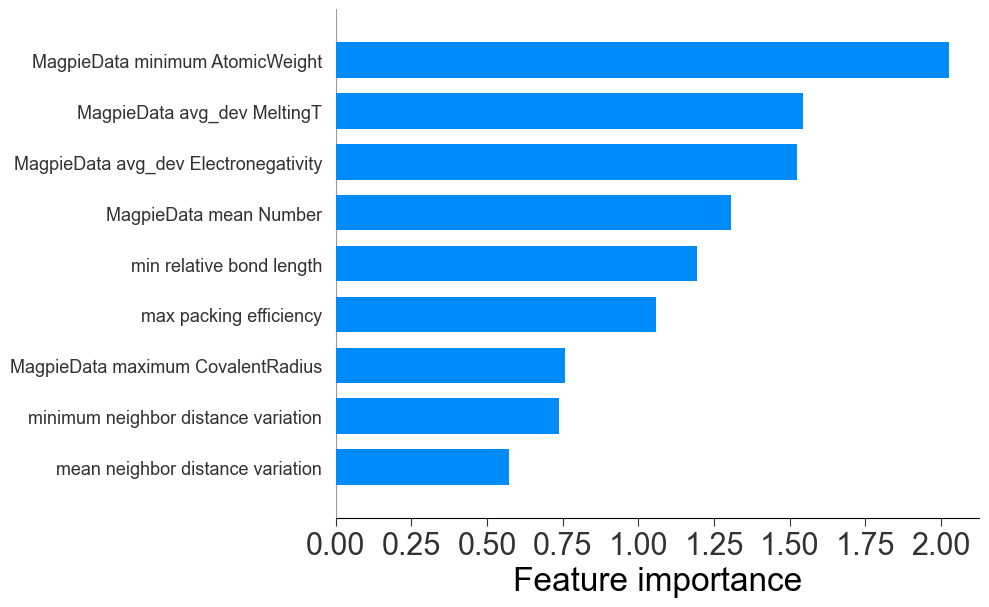

In [45]:
shap.summary_plot(shap_values, X, show=False, plot_type="bar")
fig = plt.gcf() # gcf means "get current figure"fig.set_figheight(11)fig.set_figwidth(9)
fig.set_figheight(6)
fig.set_figwidth(11.5)
plt.xticks(fontproperties = 'Arial',size = 22)
#plt.yticks(fontproperties = 'Arial',size = 22)
plt.xlabel('Feature importance', fontsize=24,family='Arial')
plt.tick_params(length=6)
#plt.savefig("shap_importance_2.svg",bbox_inches = 'tight',dpi=600) 

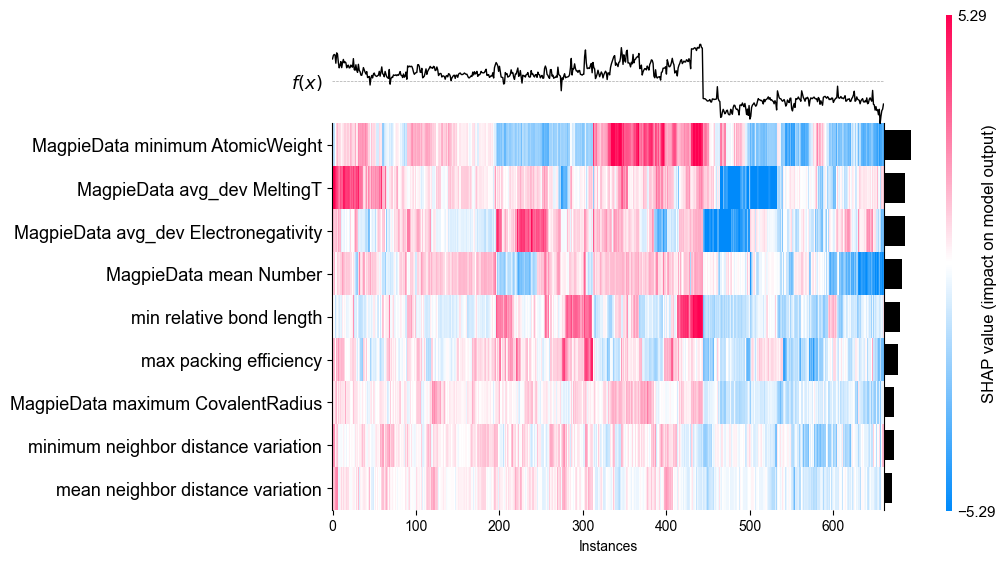

In [39]:
shap.plots.heatmap(shap_values, show=False)
#plt.savefig('shap_heatmap.tif', bbox_inches='tight', dpi=300)
plt.show()

## 2.3 Using t-SNE visualization for the overall contributions of all descriptors 

In [51]:
from sklearn.manifold import TSNE

explainer = shap.TreeExplainer(cab)
shap_values = explainer.shap_values(X)
shap_embedded = TSNE(n_components=2, perplexity=50, random_state=1998).fit_transform(shap_values)

In [52]:
shap_tsne = pd.DataFrame(shap_embedded)
shap_tsne

,0,1
0,9.883566,-0.583052
1,15.994044,1.942823
2,-0.117736,-17.305183
3,-15.636287,15.510194
4,-1.165606,-17.950556
...,...,...
656,7.358563,9.126510
657,-8.315162,9.994963
658,5.056371,0.446407
659,-1.292112,-17.241453


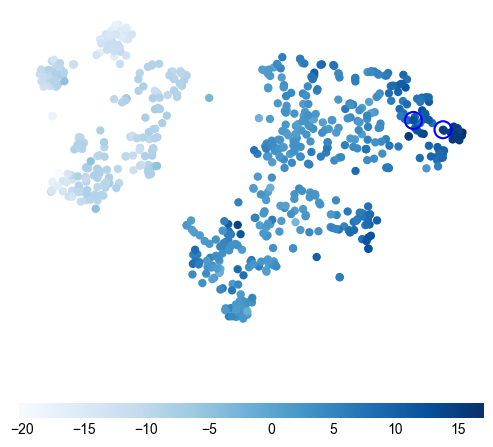

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(
    shap_embedded[:, 0],
    shap_embedded[:, 1],
    c=shap_values.sum(1).astype(np.float64),
    linewidth=0,
    alpha=1.0,
    cmap=plt.get_cmap("Blues"),
)

cb = plt.colorbar(aspect=30, orientation="horizontal")
cb.set_alpha(1)
cb.outline.set_linewidth(0)
cb.ax.tick_params("x", length=0)
cb.ax.xaxis.set_label_position("top")

X0_highlight_indices = [499, 311]
X0_highlight_points = shap_tsne.loc[X0_highlight_indices]
plt.scatter(
    X0_highlight_points.iloc[:, 0], 
    X0_highlight_points.iloc[:, 1], 
    marker='o',         
    color='b',          
    s=150,               
    edgecolors='blue',  
    facecolors='none',   
    linewidths=1.5         
)

plt.gca().axis("off")
#plt.savefig("SHAP_t-sne.svg", bbox_inches = 'tight', dpi=600) 
plt.show()

## 2.4 Local interpretability

In [54]:
X_short = X.copy()

num_columns = len(X_short.columns)
new_columns = [f'f{i}' for i in range(0, min(9, num_columns + 1))]
X_short.columns = new_columns
X_short

,f0,f1,f2,f3,f4,f5,f6,f7,f8
0,5.462055e-02,32.0650,0.311138,244,31.571429,0.924097,0.159347,217.458776,0.465306
1,1.209678e-02,39.0983,0.384463,203,31.200000,0.787531,0.090941,296.933600,0.741600
2,1.054000e-07,6.9410,0.363430,145,17.000000,0.870218,0.132359,395.405000,1.262500
3,4.406832e-02,121.7600,0.446026,144,59.333333,0.920416,0.100005,1067.653333,0.066667
4,1.442192e-16,6.9410,0.353018,145,14.333333,0.903046,0.102068,351.471111,1.122222
...,...,...,...,...,...,...,...,...,...
656,1.559733e-01,78.9600,0.312321,145,40.285714,0.944346,0.183286,101.564694,0.364898
657,5.657788e-03,72.6400,0.488542,146,60.750000,0.973891,0.025433,118.354062,0.116250
658,9.032000e-02,32.0650,0.354918,145,46.285714,0.881517,0.136979,155.211429,0.421224
659,6.322125e-04,6.9410,0.360448,139,11.777778,0.830062,0.115505,381.471111,1.152593


In [55]:
name = df[['material_id','formula_pretty']]
y = df["k_class"]
df_ = pd.concat([X_short, name, y], axis=1)
df_

,f0,f1,f2,f3,f4,f5,f6,f7,f8,material_id,formula_pretty,k_class
0,5.462055e-02,32.0650,0.311138,244,31.571429,0.924097,0.159347,217.458776,0.465306,mp-8890,Cs(SbS2)2,1
1,1.209678e-02,39.0983,0.384463,203,31.200000,0.787531,0.090941,296.933600,0.741600,mp-998412,KGeBr3,1
2,1.054000e-07,6.9410,0.363430,145,17.000000,0.870218,0.132359,395.405000,1.262500,mp-1176792,LiAgF2,1
3,4.406832e-02,121.7600,0.446026,144,59.333333,0.920416,0.100005,1067.653333,0.066667,mp-2695,Sb2Os,0
4,1.442192e-16,6.9410,0.353018,145,14.333333,0.903046,0.102068,351.471111,1.122222,mp-752768,LiAgF4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
656,1.559733e-01,78.9600,0.312321,145,40.285714,0.944346,0.183286,101.564694,0.364898,mp-1224092,In5AgSe8,1
657,5.657788e-03,72.6400,0.488542,146,60.750000,0.973891,0.025433,118.354062,0.116250,mp-1224448,GeTe4Pb3,0
658,9.032000e-02,32.0650,0.354918,145,46.285714,0.881517,0.136979,155.211429,0.421224,mp-9791,Tl3AsS3,1
659,6.322125e-04,6.9410,0.360448,139,11.777778,0.830062,0.115505,381.471111,1.152593,mp-13985,Li2PdF6,1


In [60]:
formula = df_['formula_pretty']
y = df_["k_class"].values

In [57]:
def plot_indiv_shap(i):
    shap.force_plot(explainer.expected_value, shap_values[i], X_short.iloc[[i]], show=False, matplotlib=True, contribution_threshold=0.01, plot_cmap='GnPR')

In [ ]:
# CsSnSe
index = df_.loc[df_['material_id'] == 'mp-1103379'].index
index

Int64Index([499], dtype='int64')

In [59]:
# CsGeSe
index = df_.loc[df_['material_id'] == 'mp-1102254'].index
index

Int64Index([311], dtype='int64')

In [61]:
print(formula[499], y[499])
print(formula[311], y[311])

Cs2SnSe3 1
Cs2GeSe3 1


In [62]:
large = 20; med = 20; small = 20
params = {'axes.titlesize': large,
          'legend.fontsize': 40,
          'axes.labelsize': 20,
          'axes.titlesize': 10,
          'xtick.labelsize': 24,
          'ytick.labelsize': med,
          'figure.titlesize': large}
plt.rcParams.update(params)
%matplotlib inline

### For Cs2SnSe3

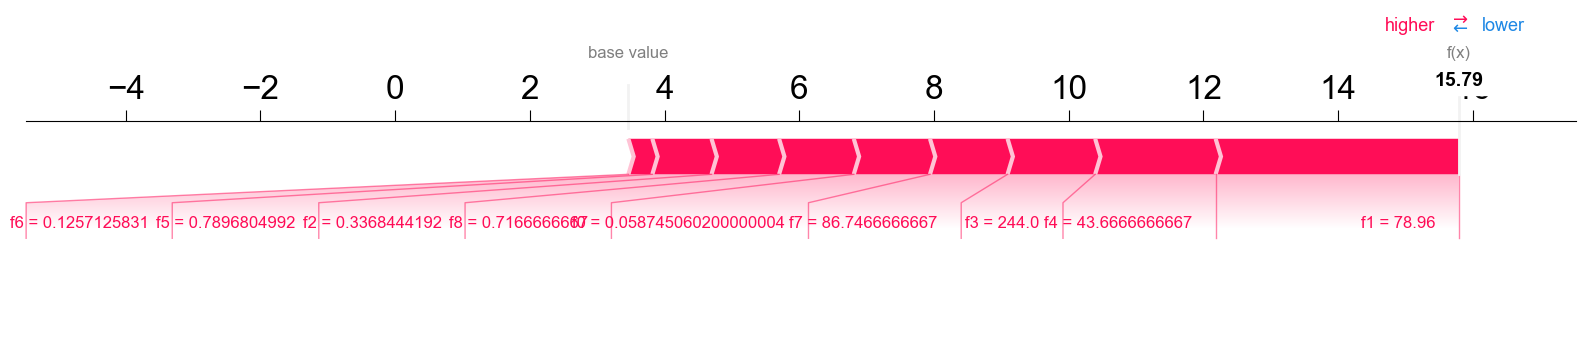

In [ ]:
plot_indiv_shap(499) 

#plt.xlim(-9,20)
#x = [-9, -6, -3, 0, 3, 6, 9, 12, 15]

plt.xticks(fontproperties = 'Arial',size = 24)
plt.tick_params(length=8)
#plt.savefig('shap_force_1.svg', bbox_inches='tight', dpi=600)
plt.show()

### For Cs2GeSe3

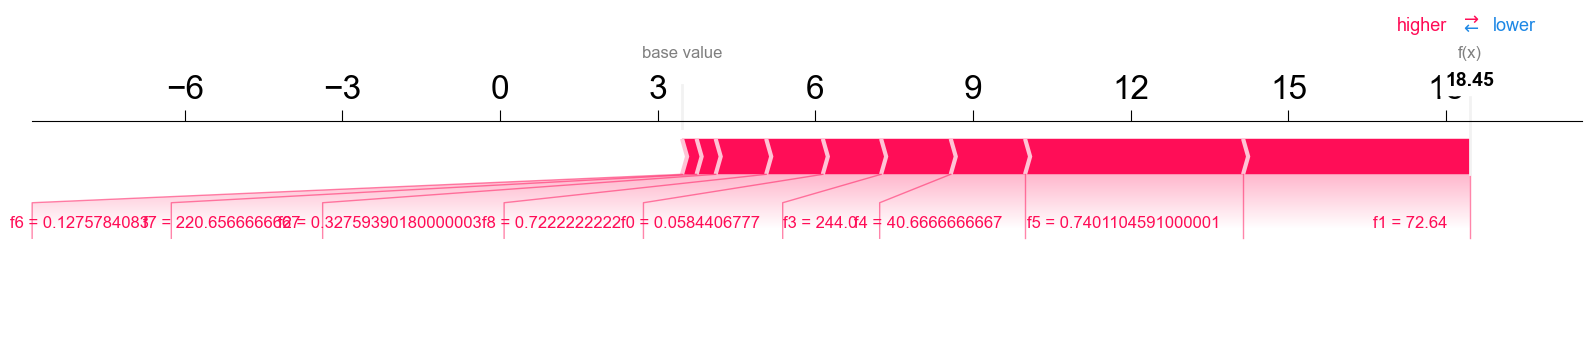

In [64]:
plot_indiv_shap(311)

#plt.xlim(-8,23)
x = [-6, -3, 0, 3, 6, 9, 12, 15, 18]
#plt.xticks(np.arange(-6, 19, 2))
plt.xticks(x, fontproperties = 'Arial',size = 24)
plt.tick_params(length=8)
#plt.savefig('shap_force_2.svg', bbox_inches='tight', dpi=600)
plt.show()

## 3. Special decriptor $L^{\mathrm{min}}$  

### $L^{\min}=\frac{\mathrm{min}\{L_i\}}{\mathrm{mean}\{L_i\}}$  

### $L_i=\frac{\sum_nA_n\cdot\left\|\overrightarrow{r_n}-\overrightarrow{r_i}\right\|_2}{\sum_nA_n}$

In [4]:
from pymatgen.analysis.local_env import VoronoiNN
from matminer.utils.caching import get_all_nearest_neighbors
from matminer.utils.caching import get_nearest_neighbors
from matminer.featurizers.utils.stats import PropertyStats
from pymatgen.core import Structure

In [5]:
df['structure'] = df['structure_json'].apply(lambda x: Structure.from_dict(x, fmt='json'))

## 3.1 For Cs2GeSe3

In [6]:
strc = df.loc[df['material_id'] == 'mp-1102254', 'structure'].values[0]
strc

Structure Summary
Lattice
    abc : 8.136133784864976 8.136133784864976 10.473460032401983
 angles : 59.75741544088605 59.75741544088605 54.93677522163012
 volume : 467.19131035530955
      A : 3.7528661 7.21877343 -0.04448783
      B : -3.7528661 7.21877343 -0.04448783
      C : 0.0 5.99835402 8.58563417
    pbc : True True True
PeriodicSite: Cs (0.0, 9.249, 1.13) [0.5834, 0.5834, 0.1376]
PeriodicSite: Cs (0.0, 11.19, 7.367) [0.4166, 0.4166, 0.8624]
PeriodicSite: Cs (0.0, 13.52, 2.674) [0.8037, 0.8037, 0.3198]
PeriodicSite: Cs (0.0, 6.914, 5.823) [0.1963, 0.1963, 0.6802]
PeriodicSite: Ge (0.0, 3.588, 2.728) [0.116, 0.116, 0.3189]
PeriodicSite: Ge (0.0, 16.85, 5.769) [0.884, 0.884, 0.6811]
PeriodicSite: Se (0.0, 2.208, 0.8869) [0.1095, 0.1095, 0.1044]
PeriodicSite: Se (0.0, 18.23, 7.61) [0.8905, 0.8905, 0.8956]
PeriodicSite: Se (0.0, 5.86, 2.333) [0.2917, 0.2917, 0.2747]
PeriodicSite: Se (0.0, 14.58, 6.164) [0.7083, 0.7083, 0.7253]
PeriodicSite: Se (-1.965, 10.22, 4.248) [0.2382, 0.761

### Get all nearest neighbors based on the Voronoi method

In [7]:
voro = VoronoiNN(extra_nn_info=True, weight="area")
nns = get_all_nearest_neighbors(voro, strc)
nns

[[{'site': PeriodicSite: Se (1.965, 10.22, 4.248) [0.7618, 0.2382, 0.5],
   'image': (0, 0, 0),
   'weight': 0.601602529803558,
   'site_index': 11,
   'poly_info': {'normal': array([0.51563845, 0.25433695, 0.81818684]),
    'solid_angle': 1.2777500443208174,
    'volume': 4.328065664989045,
    'face_dist': 1.9057060331990832,
    'area': 6.813326278434842,
    'n_verts': 7,
    'verts': [1948, 1949, 2296, 2295, 1953, 1952, 1951],
    'adj_neighbors': [460, 150, 115, 366, 285, 119, 204]}},
  {'site': PeriodicSite: Se (-1.965, 10.22, 4.248) [0.2382, 0.7618, 0.5],
   'image': (0, 0, 0),
   'weight': 0.6016025298035579,
   'site_index': 10,
   'poly_info': {'normal': array([-0.51563845,  0.25433695,  0.81818684]),
    'solid_angle': 1.2777500443208174,
    'volume': 4.328065664989044,
    'face_dist': 1.9057060331990832,
    'area': 6.8133262784348405,
    'n_verts': 7,
    'verts': [1948, 1951, 1954, 1955, 2571, 2572, 1950],
    'adj_neighbors': [507, 150, 105, 366, 275, 119, 194]}},
  

### Calculate the weighted average bond length for each atom

In [8]:
import numpy as np
wa_bond_lengths = np.zeros((len(strc),))

for i, nn in enumerate(nns):
    weights = [n["weight"] for n in nn]
    lengths = [n["poly_info"]["face_dist"] * 2 for n in nn]
    wa_bond_lengths[i] = PropertyStats.mean(lengths, weights)

wa_bond_lengths

array([3.8363864 , 3.8363864 , 4.00243848, 4.00243848, 2.60519412,
       2.60519412, 3.62623239, 3.62623239, 3.50258948, 3.50258948,
       3.54720211, 3.54720211])

### Calculate the min relative bond length

In [9]:
wa_bond_lengths.min()

2.6051941168724477

In [10]:
wa_bond_lengths.mean()

3.52000716238404

In [11]:
min_relative_bond_length = wa_bond_lengths.min() / wa_bond_lengths.mean()
min_relative_bond_length

0.7401104590673602

## 3.1 For Cs2SnSe3

In [12]:
strc = df.loc[df['material_id'] == 'mp-1103379', 'structure'].values[0]
strc

Structure Summary
Lattice
    abc : 7.58163038 8.346372234720725 9.669424643832754
 angles : 72.29475443795386 66.91841628053999 62.98735245663305
 volume : 495.51548296263434
      A : 0.0 7.58163038 0.0
      B : -5.37110806 3.79081519 5.14226097
      C : 5.09011804 3.79081519 7.29507995
    pbc : True True True
PeriodicSite: Cs (-1.561, 11.37, 9.805) [0.6896, 0.9378, 0.683]
PeriodicSite: Cs (1.28, 3.791, 2.632) [0.3104, 0.06215, 0.317]
PeriodicSite: Cs (2.79, 11.37, 7.883) [0.915, 0.3025, 0.8674]
PeriodicSite: Cs (-3.071, 3.791, 4.554) [0.08496, 0.6975, 0.1326]
PeriodicSite: Sn (-0.7977, 7.582, 4.571) [0.6211, 0.445, 0.3129]
PeriodicSite: Sn (0.5167, 7.582, 7.867) [0.3789, 0.555, 0.6871]
PeriodicSite: Se (-3.238, 7.582, 4.155) [0.6141, 0.685, 0.08675]
PeriodicSite: Se (2.957, 7.582, 8.282) [0.3859, 0.315, 0.9133]
PeriodicSite: Se (0.7335, 7.582, 2.623) [0.8022, 0.1224, 0.2733]
PeriodicSite: Se (-1.015, 7.582, 9.814) [0.1978, 0.8776, 0.7267]
PeriodicSite: Se (-0.1405, 9.505, 6.219) 

In [13]:
voro = VoronoiNN(extra_nn_info=True, weight="area")
nns = get_all_nearest_neighbors(voro, strc)
nns

[[{'site': PeriodicSite: Se (-0.1405, 9.505, 6.219) [0.7537, 0.5, 0.5],
   'image': (0, 0, 0),
   'weight': 0.5509373226312864,
   'site_index': 10,
   'poly_info': {'normal': array([ 0.33135007, -0.43566299, -0.83690196]),
    'solid_angle': 0.9248798436337504,
    'volume': 3.950059251142938,
    'face_dist': 2.14287313248895,
    'area': 5.530041687379232,
    'n_verts': 6,
    'verts': [1051, 113, 336, 1521, 1604, 1603],
    'adj_neighbors': [210, 105, 364, 59, 333, 450]}},
  {'site': PeriodicSite: Sn (0.5167, 7.582, 7.867) [0.3789, 0.555, 0.6871],
   'image': (0, 0, 0),
   'weight': 0.06762226363588514,
   'site_index': 5,
   'poly_info': {'normal': array([ 0.43846468, -0.80016069, -0.40925736]),
    'solid_angle': 0.09728291720776915,
    'volume': 0.5359437245364234,
    'face_dist': 2.368778917990071,
    'area': 0.6787594913980105,
    'n_verts': 4,
    'verts': [1522, 1605, 1604, 1521],
    'adj_neighbors': [406, 105, 364, 252]}},
  {'site': PeriodicSite: Cs (2.79, 11.37, 7.8

In [14]:
import numpy as np
wa_bond_lengths = np.zeros((len(strc),))

for i, nn in enumerate(nns):
    weights = [n["weight"] for n in nn]
    lengths = [n["poly_info"]["face_dist"] * 2 for n in nn]
    wa_bond_lengths[i] = PropertyStats.mean(lengths, weights)

wa_bond_lengths

array([4.05250635, 4.05250635, 3.8683851 , 3.8683851 , 2.85623481,
       2.85623481, 3.701716  , 3.701716  , 3.58172518, 3.58172518,
       3.64113203, 3.64113203])

In [15]:
wa_bond_lengths.min()

2.85623481329425

In [16]:
wa_bond_lengths.mean()

3.616949913578934

In [17]:
min_relative_bond_length = wa_bond_lengths.min() / wa_bond_lengths.mean()
min_relative_bond_length

0.7896804991883439